<a href="https://colab.research.google.com/github/broadinstitute/BE3D/blob/main/BEClust3Dv4_SingleScreen_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# README
- This is an example for DNMT3A which is based on a CBE screen

# Setup

In [ ]:
# @title Install DSSP and ClustalO

! apt-get update
! apt-get install dssp clustalo

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://cli.github.com/packages stable/main amd64 Packages [346 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,006 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InReleas

In [ ]:
# @title Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# @title Install BE3D

! pip install git+https://github.com/broadinstitute/beclust3d-public.git
print('beclust3d installed at:')
! pip show beclust3d


  Cloning https://github.com/broadinstitute/beclust3d-public.git to /tmp/pip-req-build-o1tei47c
  Running command git clone --filter=blob:none --quiet https://github.com/broadinstitute/beclust3d-public.git /tmp/pip-req-build-o1tei47c
  Resolved https://github.com/broadinstitute/beclust3d-public.git to commit 6ab0ed8764538224bbb1df427c12d40e991623bb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 41.1 MB/s eta 0:00:00
  Created wheel for beclust3d: filename=beclust3d-1.0.0-py3-none-any.whl size=1317667 sha256=38185a4acc28e20c81a5f812d5ac7b282669a5f4667aa3d58f73741a72011eba
  Stored in directory: /tmp/pip-ephem-wheel-cache-4gcvp9zh/wheels/f1/a7/29/932b67d47922e277bd8c92943ec17ff5105d711c221cc4f642
  Created wheel for wget: filename

In [ ]:
# @title Download relevant files

! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/data/LueNatChemBiol2022-DNMT3A-CBE.tsv -O LueNatChemBiol2022-DNMT3A-CBE.tsv

--2025-09-11 04:34:11--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/data/LueNatChemBiol2022-DNMT3A-CBE.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 55719 (54K) [text/plain]
Saving to: ‘LueNatChemBiol2022-DNMT3A-CBE.tsv’

LueNatChemBiol2022- 100%[===================>]  54.41K  --.-KB/s    in 0.008s  

2025-09-11 04:34:11 (6.93 MB/s) - ‘LueNatChemBiol2022-DNMT3A-CBE.tsv’ saved [55719/55719]



In [ ]:
# @title Import packages

import os
import sys
import yaml
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gc
import uuid
import ipywidgets as widgets
from IPython.display import display

from IPython.display import Image, display, SVG
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from google.colab import files
import shutil

from beclust3d import *


# Input

In [ ]:
# @title Required (filled with default values for DNMT3A)

# @markdown Input Gene and UniprotID (for AF2 structure)
input_gene = 'DNMT3A' # @param {type:"string"}
input_uniprot = 'Q9Y6K1' # @param {type:"string"}
structureid = f"AF-{input_uniprot}-F1-model_v4"

# @markdown Screen File (TSV)
screen_dir = '' # @param {type:"string"}
screens = 'LueNatChemBiol2022-DNMT3A-CBE.tsv' # @param {type:"string"}

mut_list_col = ""
mut_col = "Mut_type" # @param {type:"string"}
val_col = "sgRNA_score" # @param {type:"string"}
gene_col = "Gene" # @param {type:"string"}
edits_col = "Mutation_list" # @param {type:"string"}
gRNA_col = "gRNA_Seq" # @param {type:"string"}

# @markdown ---

# @markdown # Optional
qa_passed_only = False # @param {type:"boolean"}
function_for_lfc = 'max' #@param {type:"string"}
function_for_lfc3d = 'mean' #@param {type:"string"}

nRandom = 500 #@param
single_pthr = 0.05 #@param
single_pthr_str = str(single_pthr).split('.')[1]

# @markdown Where files and plots are stored:
workdir = '' # @param {type:"string"}
job_id = '' # @param {type:"string"}

# @markdown Radius to calculate LFC3D over:
structure_radius = 6.0 # @param {type:"number"}
# @markdown Radius to cluster over:
clustering_radius = 6.0 # @param {type:"number"}

# @markdown Optional user-provided filepaths
user_fasta = '' # @param {type:"string"}
if len(user_fasta) == 0: user_fasta = None
user_pdb = '' # @param {type:"string"}
if len(user_pdb) == 0: user_pdb = None
user_dssp = '' # @param {type:"string"}
if len(user_dssp) == 0: user_dssp = None
input_chain = 'A' # @param {type:"string"}

# Load screen names and dataframes
if len(screens) == 0:
    screens = [f for f in os.listdir(screen_dir) if os.path.isfile(workdir+screen_dir + '/' + f)]
else:
    screens = screens.split(',')
screen_names = [s.split('.')[0] for s in screens]
input_dfs = [pd.read_csv(screen_dir+s, sep='\t') for s in screens]

# @markdown Mutation parameters
mut_categories = ["Nonsense", "Splice Site", "Missense", "No Mutation", "Silent"] # @param {type:"raw"}
mut_delimiter = ';' # @param {type:"string"}
prioritize_by_sequence_mutations = ['Missense', 'Silent', 'Nonsense']
hypothesis_case_mutations = ['Nonsense', 'Splice Site']
hypothesis_control_mutations = ['Silent', 'No Mutation']

# @markdown Conservation parameters
target_res_pos = 'human_res_pos' # @param {type:"string"}
target_res = 'unires' # @param {type:"string"}
alternate_res_pos = 'mouse_res_pos' # @param {type:"string"}
alternate_res = 'mouse_res' # @param {type:"string"}

# Assign job ID and create an output directory
if len(job_id) == 0:
    job_id = str(uuid.uuid4())
    print(f"Job ID: {job_id}")

output_dir = os.path.join(workdir, f'{input_gene}-Job-{job_id}')
os.makedirs(output_dir, exist_ok=True)
print('All results will be saved in the following directory:')
print(output_dir)


Job ID: 3c67dce4-c830-48e4-b112-d2db50db1c62
All results will be saved in the following directory:
DNMT3A-Job-3c67dce4-c830-48e4-b112-d2db50db1c62


In [ ]:
# @title Required (yml file input)

def load_config(config_yaml):
    with open(config_yaml, "r") as file:
        config = yaml.safe_load(file)
    return config

config_yaml = '' #@param {type:"string"}
config = load_config(config_yaml)

# Parameters

beclust3d_path = config['beclust3d_path']

input_gene = config['input_gene']
input_uniprot = config['input_uniprot']
structureid = f"AF-{input_uniprot}-F1-model_v4"

screen_dir = config['screen_dir']
screens = config['screens']

mut_list_col = config['database']['mut_list_col']
mut_col = config['database']['mut_col']
val_col = config['database']['val_col']
gene_col = config['database']['gene_col']
edits_col = config['database']['edits_col']
gRNA_col = config['database']['gRNA_col']

qa_passed_only = config['qa_passed_only']
function_for_lfc = config['function_for_lfc']
function_for_lfc3d = config['function_for_lfc3d']

nRandom = config['nRandom']
single_pthr = config['pthr']['single_screen']
single_pthr_str = str(single_pthr).split('.')[1]

workdir = config['workdir']
structure_radius = config['structure_radius']
clustering_radius = config['clustering_radius']

user_fasta = config['user_fasta']
user_pdb = config['user_pdb']
user_dssp = config['user_dssp']
input_chain = config['input_chain']

if len(screens) == 0:
    screens = [f for f in os.listdir(screen_dir) if os.path.isfile(workdir+screen_dir + '/' + f)]
else:
    screens = screens.split(', ')
screen_names = [s.split('.')[0] for s in screens]
input_dfs = [pd.read_csv(screen_dir+s, sep='\t') for s in screens]

mutation_category = config['mutation_category']
mut_categories = list()
mut_categories.extend(config['mutation_category']['nonsense'])
mut_categories.extend(config['mutation_category']['splice_site'])
mut_categories.extend(config['mutation_category']['missense'])
mut_categories.extend(config['mutation_category']['silent'])
mut_categories.extend(config['mutation_category']['no_mutation'])
mut_categories.extend(config['mutation_category']['intron'])
mut_delimiter = config['database']['mut_delimiter']
prioritize_by_sequence_mutations = list()
prioritize_by_sequence_mutations.extend(config['mutation_category']['missense'])
prioritize_by_sequence_mutations.extend(config['mutation_category']['silent'])
prioritize_by_sequence_mutations.extend(config['mutation_category']['nonsense'])

hypothesis_case_mutations = list()
hypothesis_case_mutations.extend(config['mutation_category']['nonsense'])
hypothesis_case_mutations.extend(config['mutation_category']['splice_site'])
hypothesis_control_mutations = list()
hypothesis_control_mutations.extend(config['mutation_category']['no_mutation'])
hypothesis_control_mutations.extend(config['mutation_category']['silent'])

# @markdown Conservation parameters
target_res_pos = 'human_res_pos' # @param {type:"string"}
target_res = 'unires' # @param {type:"string"}
alternate_res_pos = 'mouse_res_pos' # @param {type:"string"}
alternate_res = 'mouse_res' # @param {type:"string"}

job_id = str(uuid.uuid4())
print(f"Job ID: {job_id}")
workdir = config['output_dir']
output_dir = os.path.join(workdir, f'{input_gene}-Job-{job_id}')
os.makedirs(output_dir, exist_ok=True)
print('All results will be saved in the following directory:')
print(output_dir)


Job ID: 01eeeffc-8142-4204-832a-e6a9618083eb
All results will be saved in the following directory:
/content/MORC2-Job-01eeeffc-8142-4204-832a-e6a9618083eb


# Running BE3D

In [ ]:
# @title Running the pipeline: parse sequence and conservation alignment with MUSCLE

struc_df = sequence_structural_features(
    output_dir,
    input_gene, input_uniprot, structureid,
    user_fasta=user_fasta,
    user_pdb=user_pdb,
    user_dssp=user_dssp,
    chains=[input_chain],
    radius=structure_radius,
    )

conserv_dfs = list()
gene_list = list()

for screen_name in screen_names:
      conserv_dfs.append(None)
      gene_list.append(input_gene)


In [ ]:
# @title Running the pipeline: preprocessing and prioritizing LFC

# For all screens
hypothesis_test(
    output_dir,
    input_dfs, screen_names,
    cases=hypothesis_case_mutations,
    controls=hypothesis_control_mutations,
    comp_name='NonsenseSplice_vs_SilentNoMut',
    mut_col=mut_col,
    val_col=val_col,
    gene_col=gene_col,
    save_type='svg',
    )

# If we only want to run the pipeline on screens passing QC
if qa_passed_only:
    h2_ks_test_pd = pd.read_csv(f'{output_dir}/hypothesis_qc/KolmogorovSmirnov_hypothesis2.tsv', sep='\t')
    h2_ks_test_pd = h2_ks_test_pd.replace(-999, None)
    white_screen_list = h2_ks_test_pd[
        (h2_ks_test_pd['p_NonsenseSplice_vs_SilentNoMut']<0.05) & (h2_ks_test_pd['gene_name'].isin(gene_list))]['screenid'].to_list()
    print(f'Original screen size: {len(screen_names)}')
    print(f'Screen white list size: {len(white_screen_list)}')
    print('QA-passed screen size: {len(list(set(screen_names).intersection(white_screen_list)))}')

    screen_names = list(set(screen_names).intersection(white_screen_list))
    assert len(screen_names) > 0, 'No QA-passed screens found'
    input_dfs = [pd.read_csv(os.path.join(screen_dir, f'{s}.tsv'), sep='\t') for s in screen_names]

# For all screens
parse_be_data(
    output_dir,
    input_dfs, input_gene, screen_names,
    mut_col=mut_col,
    val_col=val_col,
    gene_col=gene_col,
    edits_col=edits_col,
    mut_categories=mut_categories,
    mut_delimiter=mut_delimiter,
    conserv_dfs = conserv_dfs,
    conserv_col=alternate_res_pos,
    gene_list=gene_list,
    )
plot_rawdata(
    output_dir,
    input_dfs,
    screen_names,
    mut_col=mut_col,
    val_col=val_col,
    gene_col=gene_col,
    mut_categories=mut_categories,
    )

# For all screens
df_missense_list = [
    pd.read_csv(f'{output_dir}/screendata/{gene}_{screen_name}_Missense.tsv',
                sep='\t') for gene, screen_name in zip(gene_list, screen_names)
]

# For all screens
for df_missense, screen_name, gene in zip(df_missense_list, screen_names, gene_list):
    randomize_data(
        df_missense,
        output_dir, gene,
        screen_name,
        nRandom=nRandom,
        seed=True,
        )

df_struc = pd.read_csv(f'{output_dir}/sequence_structure/{structureid}_coord_struc_features.tsv', sep='\t')

# For all screens (human and non-human mixed)
for gene, screen_name, df_consrv in zip(gene_list, screen_names, conserv_dfs):
    df_control = pd.read_csv(f'{output_dir}/screendata/{gene}_{screen_name}_No_Mutation.tsv', sep='\t', index_col=0)
    df_dict = {}

    for mut in prioritize_by_sequence_mutations:
        filepath = f'{output_dir}/screendata/{gene}_{screen_name}_{mut}.tsv'
        if os.path.exists(filepath):
            df_dict[mut] = pd.read_csv(filepath, sep='\t', index_col=0)

    if df_consrv is not None:
        df_missense = prioritize_by_sequence(
            df_dict,
            df_struc, df_consrv, df_control,
            output_dir,
            gene, screen_name,
            target_res_pos=target_res_pos,
            alt_res_pos=alternate_res_pos,
            alt_res=alternate_res
        )
    else:
        df_missense = prioritize_by_sequence(
            df_dict,
            df_struc, df_consrv, df_control,
            output_dir,
            gene, screen_name
        )

    df_rand = pd.read_csv(f'{output_dir}/screendata_rand/{gene}_{screen_name}_Missense_rand.tsv', sep='\t')

    # For all screens
    randomize_sequence(
        df_missense, df_rand,
        output_dir,
        gene, screen_name,
        nRandom=nRandom, conservation=False,
        muttype='Missense',
        function_name=function_for_lfc,
        target_pos='unipos', target_res=None,
        )

    plot_screendata_sequence(
        df_missense,
        output_dir,
        gene, screen_name, function_name=function_for_lfc, muttype='Missense',
    )


Processing LueNatChemBiol2022-DNMT3A-CBE
{'Nonsense': 18, 'Splice Site': 12, 'Missense': 204, 'No Mutation': 166, 'Silent': 88}


In [ ]:
# @title Running the pipeline: BE Clust3D calculating LFC3D score per residue

def find_union(input, pthr_str):
    if input[0] == f'p<{pthr_str}' or input[1] == f'p<{pthr_str}':
        return f'p<{pthr_str}'
    else:
        return f'p>={pthr_str}'

def run_Clust3D_per_species(gene, screen_names):

    # CLUSTERING ON PRIORITIZED
    df_struc = pd.read_csv(f'{output_dir}/sequence_structure/{structureid}_coord_struc_features.tsv', sep='\t')
    df_edits_list = []
    df_rand_list = []

    for screen_name in screen_names:
        df_missense = pd.read_csv(f'{output_dir}/screendata_sequence/{gene}_{screen_name}_protein_edits.tsv', sep='\t')
        temp_plab_label, temp_p_label = f'{function_for_lfc}_Missense_LFC_plab_input', f'{function_for_lfc}_Missense_LFC_p'
        df_missense[temp_plab_label] = df_missense[temp_p_label].apply(lambda x: f'p<{single_pthr_str}' if x < single_pthr else f'p>={single_pthr_str}')

        df_hits_clust, distances, yvalues = clustering(
            df_struc, df_missense,
            output_dir, gene,
            psig_columns=[temp_plab_label],
            pthr_cutoffs=[f'p<{single_pthr_str}'],
            screen_name=screen_name, score_type='lfc',
            max_distances=25, merge_cols=['unipos', 'chain'],
        )

        df_protein_edits = pd.read_csv(f'{output_dir}/screendata_sequence/{gene}_{screen_name}_protein_edits.tsv', sep='\t')
        df_edits_list.append(df_protein_edits)
        df_protein_edits_rand = pd.read_csv(f'{output_dir}/screendata_sequence_rand/{gene}_{screen_name}_Missense_protein_edits_rand.tsv', sep='\t')
        df_rand_list.append(df_protein_edits_rand)

    df_LFC_LFC3D = calculate_lfc3d(
        df_struc, df_edits_list, df_rand_list,
        output_dir, gene, screen_names,
        nRandom=nRandom,  muttype='Missense',
        function_type_lfc=function_for_lfc,
        function_type_lfc3d=function_for_lfc3d,
        conserved_only=False,
    )

    # LFC #
    df_bidir = average_split_score(
        df_LFC_LFC3D,
        output_dir, gene, screen_names,
        score_type='LFC',
    )
    df_dis, _, _ = bin_score(
        df_bidir,
        output_dir, gene, screen_names,
        score_type='LFC',
    )
    znorm_score(
        df_bidir, output_dir, gene, screen_names,
        pthrs=[0.05, 0.01, 0.001], score_type='LFC',
    )
    df_lfc = pd.read_csv(f'{output_dir}/LFC/{gene}_NonAggr_LFC.tsv', sep='\t')

    for screen_name in screen_names:
        average_split_bin_plots(
            df_lfc,
            workdir = output_dir,
            input_gene = gene,
            screen_name=screen_name, # BLANK FOR META #
            func='', # BLANK FOR NON AGGR #
            pthr=single_pthr,
            score_type='LFC',
            aggregate_dir='LFC',
            save_type='svg'
            )

    # LFC3D #
    df_bidir = average_split_score(
        df_LFC_LFC3D,
        output_dir, gene, screen_names,
        score_type='LFC3D',
    )
    df_dis, _, _ = bin_score(
        df_bidir,
        output_dir, gene, screen_names,
        score_type='LFC3D',
    )
    znorm_score(
        df_bidir, output_dir, gene, screen_names,
        pthrs=[0.05, 0.01, 0.001], score_type='LFC3D'
    )
    df_lfc3d = pd.read_csv(f'{output_dir}/LFC3D/{gene}_NonAggr_LFC3D.tsv', sep='\t')

    for screen_name in screen_names:
        average_split_bin_plots(
            df_lfc3d,
            workdir = output_dir,
            input_gene = gene,
            screen_name=screen_name, # BLANK FOR META #
            func='', # BLANK FOR NON AGGR #
            pthr=single_pthr,
            score_type='LFC3D',
            aggregate_dir='LFC3D',
            save_type='svg'
            )

    for score_type in ['LFC', 'LFC3D']:
        df_pvals = pd.read_csv(f'{output_dir}/{score_type}/{gene}_NonAggr_{score_type}.tsv', sep='\t')

        for screen_name in screen_names:
            df_hits_clust, distances, yvalues = clustering(
                df_struc, df_pvals,
                output_dir, gene,
                psig_columns=[
                    f'{screen_name}_{score_type}_neg_05_psig',
                    f'{screen_name}_{score_type}_pos_05_psig',
                    f'{screen_name}_{score_type}_neg_01_psig',
                    f'{screen_name}_{score_type}_pos_01_psig',
                    f'{screen_name}_{score_type}_neg_001_psig',
                    f'{screen_name}_{score_type}_pos_001_psig'
                    ],
                pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
                screen_name=screen_name, score_type=score_type,
                max_distances=20, merge_cols=['unipos', 'chain'],
            )

            # PLOTTING #
            plot_clustering(
                df_struc, df_pvals,
                df_hits_clust, clustering_radius,
                output_dir, gene,
                distances, yvalues,
                names=['Negative', 'Positive', 'Negative', 'Positive', 'Negative', 'Positive'],
                psig_columns=[
                    f'{screen_name}_{score_type}_neg_05_psig',
                    f'{screen_name}_{score_type}_pos_05_psig',
                    f'{screen_name}_{score_type}_neg_01_psig',
                    f'{screen_name}_{score_type}_pos_01_psig',
                    f'{screen_name}_{score_type}_neg_001_psig',
                    f'{screen_name}_{score_type}_pos_001_psig'
                    ],
                pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
                screen_name=screen_name, score_type=score_type,
                merge_col=['unipos', 'chain'],
                save_type='svg',
                dendrogram_subplots_kwargs={'figsize':(15, 3.5)}
            )

    for screen_name in screen_names:
        # LFC vs LFC3D SCATTERPLOT #
        df_lfc = pd.read_csv(f"{output_dir}/LFC/{gene}_NonAggr_LFC.tsv", sep='\t')
        df_lfc_dis = pd.read_csv(f"{output_dir}/LFC/{gene}_LFC_dis_wght.tsv", sep='\t')
        df_lfc3d = pd.read_csv(f"{output_dir}/LFC3D/{gene}_NonAggr_LFC3D.tsv", sep='\t')
        df_lfc3d_dis = pd.read_csv(f"{output_dir}/LFC3D/{gene}_LFC3D_dis_wght.tsv", sep='\t')

        df_dis_input = pd.DataFrame()
        df_dis_input['unipos'] = df_lfc_dis['unipos']

        df_dis_input = pd.concat([df_dis_input,
                                  df_lfc_dis.filter(regex=r'LFC$'),
                                  df_lfc3d_dis.filter(regex=r'LFC3D$'),
                                  df_lfc3d.filter(regex=fr'LFC3D_dis$|{single_pthr_str}_psig$')
                                  ])
        df_dis_input = df_dis_input.rename({f'{screen_name}_LFC3D_neg_{single_pthr_str}_psig': f'{screen_name}_LFC3D_neg_psig',
                                            f'{screen_name}_LFC3D_pos_{single_pthr_str}_psig': f'{screen_name}_LFC3D_pos_psig', }, axis=1)
        lfc_lfc3d_scatter(
            df_input=df_dis_input,
            workdir=output_dir,
            input_gene=gene, screen_name=screen_name,
            pthr=single_pthr,
        )
        os.rename(f'{output_dir}/characterization/plots/{gene}_LFC_LFC3D_scatter.png',
                  f'{output_dir}/characterization/plots/{gene}_LFC_LFC3D_scatter_{single_pthr_str}_{screen_name}.png')

    # Load both LFC and LFC3D dataframes
    df_pvals_LFC3D = pd.read_csv(f'{output_dir}/LFC3D/{gene}_NonAggr_LFC3D.tsv', sep='\t')
    df_pvals_LFC = pd.read_csv(f'{output_dir}/LFC/{gene}_NonAggr_LFC.tsv', sep='\t')
    df_pvals = pd.concat([df_pvals_LFC3D, df_pvals_LFC.drop(columns=['unipos', 'unires', 'chain'])], axis=1)

    # Find union of LFC and LFC3D
    for screen_name in screen_names:
        for each_pthr in ['05', '01', '001']:
            temp_union_label = f'{screen_name}_union_neg_{each_pthr}_psig'
            temp_lfc_labels = [f'{screen_name}_LFC_neg_{each_pthr}_psig', f'{screen_name}_LFC3D_neg_{each_pthr}_psig']
            df_pvals[temp_union_label] = df_pvals[temp_lfc_labels].apply(lambda row: find_union(row, f'0.{each_pthr}'), axis=1)
            temp_union_label = f'{screen_name}_union_pos_{each_pthr}_psig'
            temp_lfc_labels = [f'{screen_name}_LFC_pos_{each_pthr}_psig', f'{screen_name}_LFC3D_pos_{each_pthr}_psig']
            df_pvals[temp_union_label] = df_pvals[temp_lfc_labels].apply(lambda row: find_union(row, f'0.{each_pthr}'), axis=1)

        df_hits_clust, distances, yvalues = clustering(
            df_struc, df_pvals,
            output_dir, gene,
            psig_columns=[
                f'{screen_name}_union_neg_05_psig',
                f'{screen_name}_union_pos_05_psig',
                f'{screen_name}_union_neg_01_psig',
                f'{screen_name}_union_pos_01_psig',
                f'{screen_name}_union_neg_001_psig',
                f'{screen_name}_union_pos_001_psig'
                ],
            pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
            screen_name=screen_name, score_type='union',
            max_distances=20, merge_cols=['unipos', 'chain'],
        )

        # PLOTTING #
        plot_clustering(
            df_struc, df_pvals,
            df_hits_clust, clustering_radius,
            output_dir, gene,
            distances, yvalues,
            names=['Negative', 'Positive', 'Negative', 'Positive', 'Negative', 'Positive'],
            psig_columns=[
                f'{screen_name}_union_neg_05_psig',
                f'{screen_name}_union_pos_05_psig',
                f'{screen_name}_union_neg_01_psig',
                f'{screen_name}_union_pos_01_psig',
                f'{screen_name}_union_neg_001_psig',
                f'{screen_name}_union_pos_001_psig'
                ],
            pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
            screen_name = screen_name, score_type='union',
            merge_col=['unipos', 'chain'],
            save_type='svg',
            dendrogram_subplots_kwargs={'figsize':(15, 3.5)}
        )

    return df_LFC_LFC3D

merged_df_LFC_LFC3D = run_Clust3D_per_species(input_gene, [x[1] for x in zip(conserv_dfs, screen_names) if x[0] is None])

gene_list = [input_gene] * len(screen_names)
g2p_formatted_hit_cluster(
    output_dir, gene_list, screen_names,
    lfc_pthr=single_pthr_str, lfc3d_pthr=single_pthr_str,
    meta_pthr='001', meta=False,
    )


Calculated LFC3D for LueNatChemBiol2022-DNMT3A-CBE
DNMT3A LueNatChemBiol2022-DNMT3A-CBE


In [ ]:
# @title Download output directory

shutil.make_archive(output_dir, 'zip', output_dir)
files.download(f"{output_dir}.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Analysis

In [ ]:
# @title LFC, LFC3D Residue-dot Plot

screen_name = screen_names[0]

# Load LFC data
lfc_pd = pd.read_csv(f'{output_dir}/LFC/DNMT3A_NonAggr_LFC.tsv', sep='\t')
lfc_pd = lfc_pd.replace('-', None)
lfc_pd[f'{screen_name}_LFC_pos'] = pd.to_numeric(lfc_pd[f'{screen_name}_LFC_pos'], errors='coerce')

# Load LFC3D data
lfc3d_pd = pd.read_csv(f'{output_dir}/LFC3D/DNMT3A_NonAggr_LFC3D.tsv', sep='\t')
lfc3d_pd = lfc3d_pd.replace('-', None)
lfc3d_pd[f'{screen_name}_LFC3D_pos'] = pd.to_numeric(lfc3d_pd[f'{screen_name}_LFC3D_pos'], errors='coerce')

# Map significance to color arrays
lfc_colors = lfc_pd[f'{screen_name}_LFC_pos_05_psig'].map({'p<0.05': 'blue'}).fillna('gray')
lfc3d_colors = lfc3d_pd[f'{screen_name}_LFC3D_pos_05_psig'].map({'p<0.05': 'blue'}).fillna('gray')

# Shared axis ranges
x_min = min(lfc_pd['unipos'].min(), lfc3d_pd['unipos'].min())
x_max = max(lfc_pd['unipos'].max(), lfc3d_pd['unipos'].max())
y_min = min(lfc_pd[f'{screen_name}_LFC_pos'].min(), lfc3d_pd[f'{screen_name}_LFC3D_pos'].min())
y_max = max(lfc_pd[f'{screen_name}_LFC_pos'].max(), lfc3d_pd[f'{screen_name}_LFC3D_pos'].max())

# Create subplots
fig = make_subplots(
    rows=1, cols=2, subplot_titles=('LFC', 'LFC3D'),
    shared_xaxes=True, shared_yaxes=True)

# Plot LFC
fig.add_trace(go.Scatter(
    x=lfc_pd['unipos'],
    y=lfc_pd[f'{screen_name}_LFC_pos'],
    mode='markers',
    marker=dict(color=lfc_colors, size=10),
    showlegend=False
), row=1, col=1)

# Plot LFC3D
fig.add_trace(go.Scatter(
    x=lfc3d_pd['unipos'],
    y=lfc3d_pd[f'{screen_name}_LFC3D_pos'],
    mode='markers',
    marker=dict(color=lfc3d_colors, size=10),
    showlegend=False
), row=1, col=2)

# # Add horizontal reference lines at y=0
# for col in [1, 2]:
#     fig.add_shape(type='line',
#                   x0=x_min, x1=x_max,
#                   y0=0, y1=0,
#                   line=dict(color='black', width=1, dash='dot'),
#                   row=1, col=col)

# Add manual legend (dummy invisible points with legend)

fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='markers',
    marker=dict(size=10, color='blue'),
    name='p < 0.05'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='markers',
    marker=dict(size=10, color='gray'),
    name='p > 0.05'
), row=1, col=1)

# Layout and axes

fig.update_layout(
    height=600,
    width=1400,
    title_text="DNMT3A Residue-level LFC and LFC3D Plot",
    legend=dict(x=1.05, y=1, traceorder="normal"),
)

fig.update_xaxes(title_text="Residue Position", range=[x_min, x_max])
fig.update_yaxes(title_text="Signal", range=[y_min, y_max+0.3])

fig.show()

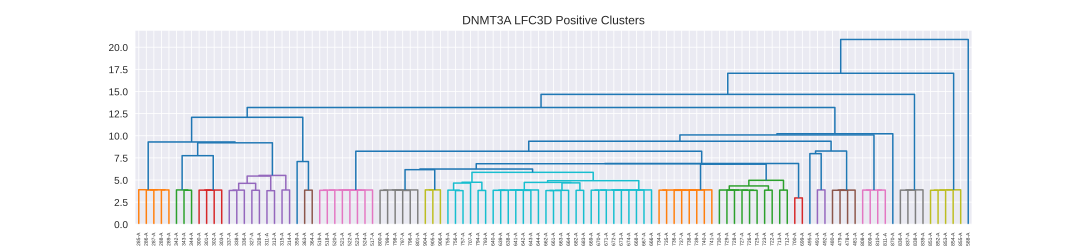

In [ ]:
# @title LFC3D Hit Clusters (Dendrogram)
display(SVG(filename=f'{output_dir}/cluster_LFC3D/plots/DNMT3A_LueNatChemBiol2022-DNMT3A-CBE_LFC3D_Positive_Dendrogram_p<0.001_6A.svg'))